# Banking Deposit Run Risk Early Warning System

## 1. Business Problem

Deposit Run Risk Early Warning System - Project Journal

Why this project?

Most banking portfolio projects focus on customer churn prediction. However, from a liquidity risk perspective, customer attrition can be interpreted as a proxy for deposit runoff events.

Therefore, this project aims to develop an Early Warning System (EWS) to identify customers at risk of deposit withdrawal and support proactive liquidity risk management.

Initial Business Hypotheses
Customers with higher balances are more likely to create material liquidity risk when they leave.
Inactive customers have higher runoff risk.
Customers using multiple banking products are more sticky and less likely to leave.
Relationship tenure is negatively associated with runoff risk.
Historical behavioural variables would be stronger predictors than demographic variables if available.
Potential Feature Ideas
Balance / Salary
Balance / Number of Products
Age Band
Balance Band
Customer Value Score
Dataset Limitations

The Kaggle dataset does not contain:

Transaction history
Deposit inflow/outflow trend
Salary payment history
Digital banking activity
Historical account activity

These variables would likely improve model performance in a production banking environment.

## 2. Dataset Overview

In [1]:
import pandas as pd
import numpy as np
from os import getcwd


In [2]:
import sys
print(sys.executable)

h:\Project\deposit-run-risk-ews\.venv\Scripts\python.exe


In [3]:
df=pd.read_csv(getcwd()+r'\data\Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df["Exited"].value_counts(normalize=True))


Shape:
(10000, 14)

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Target distribution:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


## 4. Model Development

### Baseline model Logistic Regression

In [5]:
import os
import sys
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

print("Python executable:")
print(sys.executable)

df=pd.read_csv(getcwd()+r'\data\Churn_Modelling.csv')
df.head()

# =========================
# 1. Define target and features
# =========================

drop_cols = ["RowNumber", "CustomerId", "Surname", "Exited"]

X = df.drop(columns=drop_cols)
y = df["Exited"]

# =========================
# 2. Train-test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 3. Preprocessing
# =========================

cat_cols = ["Geography", "Gender"]
num_cols = [col for col in X.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

# =========================
# 4. Logistic Regression baseline
# =========================

logit_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

logit_model.fit(X_train, y_train)

# =========================
# 5. Evaluation
# =========================

y_pred_prob = logit_model.predict_proba(X_test)[:, 1]
y_pred = logit_model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\n==============================")
print("Baseline Logistic Regression")
print("==============================")

print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Python executable:
h:\Project\deposit-run-risk-ews\.venv\Scripts\python.exe

Baseline Logistic Regression
ROC-AUC: 0.7772

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000


Confusion Matrix:
[[1142  451]
 [ 122  285]]


### Key Finding #1

Baseline Logistic Regression achieved ROC-AUC of 0.772.

For an Early Warning System, recall was prioritised over precision because missing a true runoff customer (false negative) is potentially more costly than issuing an unnecessary warning (false positive).

The baseline model successfully identified approximately 70% of runoff events.


## 5. Feature engineering

### Key Finding #2

Business-driven feature engineering significantly improved model performance.

By introducing behavioural and relationship-based features such as:

- BalanceSalaryRatio
- BalancePerProduct
- AgeTenureRatio
- HighBalanceInactive
- CustomerValue

ROC-AUC improved from 0.777 to 0.810.

This suggests that domain knowledge contributes more value than algorithm complexity in the early stages of model development.

In [6]:
# BalanceSalaryRatio
df["BalanceSalaryRatio"] = (
    df["Balance"] /
    (df["EstimatedSalary"] + 1)
)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035


In [7]:
# BalancePerProduct
df["BalancePerProduct"] = (
    df["Balance"] /
    (df["NumOfProducts"] + 1)
)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,BalancePerProduct
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.00
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,41903.93
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,39915.20
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,0.00
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,62755.41


In [8]:
# AgeTenureRatio
df["AgeTenureRatio"] = (
    df["Age"] /
    (df["Tenure"] + 1)
)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,BalancePerProduct,AgeTenureRatio
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.00,14.000000
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,41903.93,20.500000
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,39915.20,4.666667
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,0.00,19.500000
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,62755.41,14.333333


In [9]:
# HighBalanceInactive
median_balance = df["Balance"].median()

df["HighBalanceInactive"] = (
    (df["Balance"] > median_balance)
    &
    (df["IsActiveMember"] == 0)
).astype(int)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,BalancePerProduct,AgeTenureRatio,HighBalanceInactive
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.00,14.000000,0
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,41903.93,20.500000,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,39915.20,4.666667,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,0.00,19.500000,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,62755.41,14.333333,0


In [10]:
# Customer Value
df["CustomerValue"] = (
    df["Balance"]
    * df["NumOfProducts"]
)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,BalancePerProduct,AgeTenureRatio,HighBalanceInactive,CustomerValue
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.00,14.000000,0,0.00
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,41903.93,20.500000,0,83807.86
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,39915.20,4.666667,1,478982.40
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,0.00,19.500000,0,0.00
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,62755.41,14.333333,0,125510.82


### Re-train model Logistic Regression after Feature engineering

In [11]:
# 1. Define target and features
# =========================

drop_cols = ["RowNumber", "CustomerId", "Surname", "Exited"]

X = df.drop(columns=drop_cols)
y = df["Exited"]

# =========================
# 2. Train-test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 3. Preprocessing
# =========================

cat_cols = ["Geography", "Gender"]
num_cols = [col for col in X.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

# =========================
# 4. Logistic Regression
# =========================

logit_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

logit_model.fit(X_train, y_train)

# =========================
# 6. Evaluation
# =========================

y_pred_prob = logit_model.predict_proba(X_test)[:, 1]
y_pred = logit_model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\n==============================")
print("Logistic Regression + Feature Engineering")
print("==============================")

print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Logistic Regression + Feature Engineering
ROC-AUC: 0.8095

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1593
           1       0.43      0.74      0.55       407

    accuracy                           0.75      2000
   macro avg       0.68      0.75      0.69      2000
weighted avg       0.82      0.75      0.77      2000


Confusion Matrix:
[[1198  395]
 [ 106  301]]


### Key Finding #3

A key finding from the project was that domain-driven feature engineering improved model performance more significantly than model complexity.

By introducing behavioural and relationship-based features such as BalanceSalaryRatio, BalancePerProduct and HighBalanceInactive, ROC-AUC increased from 0.777 to 0.810 without changing the underlying algorithm.

This highlighted the importance of business understanding and behavioural modelling in banking analytics.

## 6. Model Explainability

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import pandas as pd

In [13]:
# =========================
# X / y
# =========================

X = df.drop(
    columns=[
        "RowNumber",
        "CustomerId",
        "Surname",
        "Exited"
    ]
)

y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# =========================
# Preprocessing
# =========================

cat_cols = ["Geography", "Gender"]
num_cols = [col for col in X.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

In [15]:
# =========================
# Model Benchmarking
# =========================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}

results = []
trained_models = {}

for model_name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)

    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "ROC_AUC": round(auc, 4)
    })

    trained_models[model_name] = pipe

results_df = pd.DataFrame(results).sort_values(
    by="ROC_AUC",
    ascending=False
)

results_df

,Model,ROC_AUC
2,XGBoost,0.8652
1,Random Forest,0.8645
0,Logistic Regression,0.8095


In [16]:
for model_name, pipe in trained_models.items():
    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)

    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)

    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression
ROC-AUC: 0.8095

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1593
           1       0.43      0.74      0.55       407

    accuracy                           0.75      2000
   macro avg       0.68      0.75      0.69      2000
weighted avg       0.82      0.75      0.77      2000


Confusion Matrix:
[[1198  395]
 [ 106  301]]

Random Forest
ROC-AUC: 0.8645

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.87      1593
           1       0.53      0.75      0.62       407

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.82      2000


Confusion Matrix:
[[1316  277]
 [ 100  307]]

XGBoost
ROC-AUC: 0.8652

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97 

### Model Benchmark Results

| Model | ROC-AUC |
|---------|---------|
| Logistic Regression | 0.8095 |
| Random Forest | 0.8645 |
| XGBoost | 0.8652 |

### Key Findings #4

1. XGBoost achieved the best predictive performance.
2. Random Forest delivered nearly identical performance.
3. Behavioural feature engineering improved model performance substantially before any advanced algorithms were introduced.
4. Domain knowledge proved to be a key driver of model performance.

### SHAP Explainability

Objective:

Understand the key drivers behind deposit runoff risk predictions and provide transparent explanations for model outputs.

In [17]:
best_model = trained_models["XGBoost"]
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['CreditScore','Geography','Gender',...,'AgeTenureRatio', 'HighBalanceInactive','CustomerValue']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [ ]:
import os
import joblib

BASE_DIR = os.path.abspath("..")
MODEL_DIR = os.path.join(BASE_DIR,"deposit-run-risk-ews", "models")
MODEL_PATH = os.path.join(MODEL_DIR, "xgb_deposit_run_model.pkl")

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(best_model, MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

In [19]:
preprocessor = best_model.named_steps["preprocessor"]
xgb_model = best_model.named_steps["model"]

print(type(preprocessor))
print(type(xgb_model))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'xgboost.sklearn.XGBClassifier'>


In [20]:
X_test_transformed = preprocessor.transform(X_test)

print(X_test_transformed.shape)

(2000, 18)


In [21]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['cat__Geography_France' 'cat__Geography_Germany' 'cat__Geography_Spain'
 'cat__Gender_Female' 'cat__Gender_Male' 'num__CreditScore' 'num__Age'
 'num__Tenure' 'num__Balance' 'num__NumOfProducts' 'num__HasCrCard'
 'num__IsActiveMember' 'num__EstimatedSalary' 'num__BalanceSalaryRatio'
 'num__BalancePerProduct' 'num__AgeTenureRatio' 'num__HighBalanceInactive'
 'num__CustomerValue']


In [22]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_transformed)

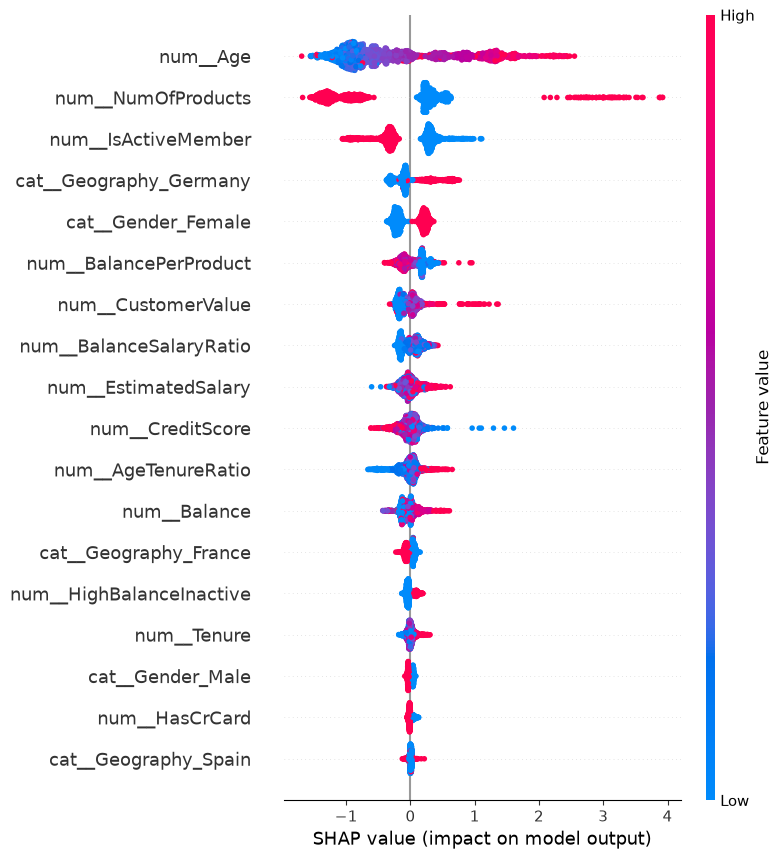

In [23]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [24]:
df.groupby("NumOfProducts")["Exited"].agg(
    Customer_Count="count",
    Churn_Rate="mean"
)

,Customer_Count,Churn_Rate
NumOfProducts,,
1,5084,0.277144
2,4590,0.075817
3,266,0.827068
4,60,1.000000


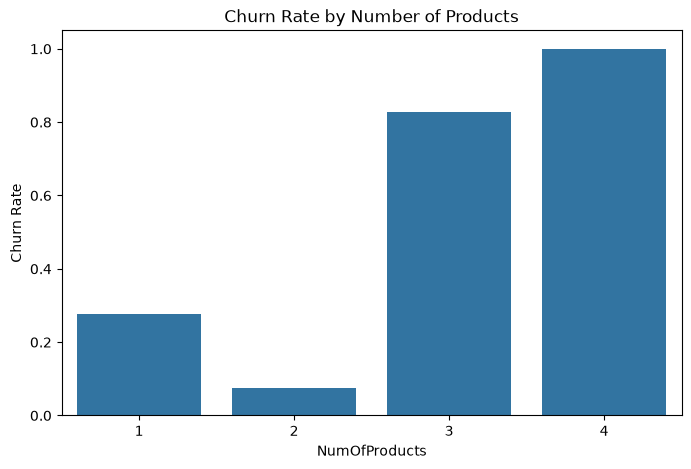

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

churn_by_product = (
    df.groupby("NumOfProducts")["Exited"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=churn_by_product,
    x="NumOfProducts",
    y="Exited"
)

plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate")
plt.show()

### Key Finding #5

- Older customers exhibit a higher probability of attrition/runoff events in the dataset, suggesting age is a key behavioural driver of customer departure.

- Contrary to the initial assumption that more products imply stronger customer stickiness represented throught NumOfProducts feature, 
the dataset exhibits a highly non-linear relationship. 
Customers with two products show the lowest churn rate, 
while customers holding three or more products display significantly elevated churn risk.

In [26]:
import numpy as np

risk_scores = best_model.predict_proba(X_test)[:,1]

highest_risk_idx = np.argmax(risk_scores)

print(highest_risk_idx)
print(risk_scores[highest_risk_idx])

501
0.9960278


In [27]:
X_test.iloc[highest_risk_idx]

CreditScore                  738
Geography                Germany
Gender                      Male
Age                           58
Tenure                         2
Balance                133745.44
NumOfProducts                  4
HasCrCard                      1
IsActiveMember                 0
EstimatedSalary         28373.86
BalanceSalaryRatio      4.713519
BalancePerProduct      26749.088
AgeTenureRatio         19.333333
HighBalanceInactive            1
CustomerValue          534981.76
Name: 70, dtype: object

In [28]:
print("Risk Score:", risk_scores[highest_risk_idx])

Risk Score: 0.9960278


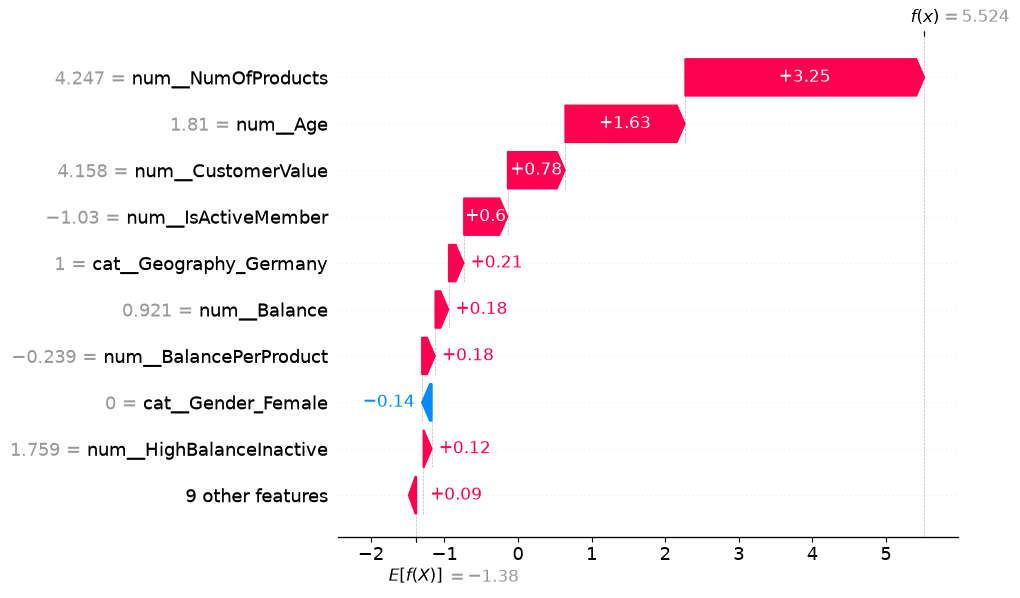

In [29]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_transformed[highest_risk_idx],
        feature_names=feature_names
    )
)

### Example Customer-Level Explanation

The model assigned a runoff risk score of 99.6% to a customer aged 58 with four banking products, a high account balance and inactive status.

SHAP analysis revealed that the strongest contributors were:

* Number of Products (+3.25)
* Age (+1.63)
* Customer Value (+0.78)
* Inactive Membership (+0.60)

This demonstrates how the Early Warning System provides transparent explanations rather than black-box predictions.

The dataset exhibits a strong non-linear relationship between product holdings and attrition. Customers holding four products demonstrate extremely high churn rates. Further investigation is required to determine whether this pattern reflects genuine customer behaviour or a data-generation artifact.

Not all statistically significant patterns are necessarily business-causal. Some may arise from data-generation processes, sampling effects, or hidden structural characteristics of the dataset.

In [30]:
df.groupby("NumOfProducts").agg(
    Customer_Count=("Exited","count"),
    Churn_Rate=("Exited","mean"),
    Avg_Balance=("Balance","mean"),
    Avg_Age=("Age","mean")
)

,Customer_Count,Churn_Rate,Avg_Balance,Avg_Age
NumOfProducts,,,,
1,5084,0.277144,98551.870614,39.673092
2,4590,0.075817,51879.145813,37.753595
3,266,0.827068,75458.328195,43.195489
4,60,1.000000,93733.135000,45.683333


## 7. Risk Segmentation

In [31]:
risk_result = X_test.copy()

risk_result["Runoff_Probability"] = risk_scores
risk_result

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,BalancePerProduct,AgeTenureRatio,HighBalanceInactive,CustomerValue,Runoff_Probability
5702,585,France,Male,36,7,0.00,2,1,0,94283.09,0.000000,0.000000,4.500000,0,0.00,0.016673
3667,525,Germany,Male,33,4,131023.76,2,0,0,55072.93,2.379052,43674.586667,6.600000,1,262047.52,0.050596
1617,557,Spain,Female,40,4,0.00,2,0,1,105433.53,0.000000,0.000000,8.000000,0,0.00,0.033751
5673,639,Spain,Male,34,5,139393.19,2,0,0,33950.08,4.105707,46464.396667,5.666667,1,278786.38,0.040535
4272,640,Spain,Female,34,3,77826.80,1,1,1,168544.85,0.461754,38913.400000,8.500000,0,77826.80,0.081911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5768,674,France,Male,36,2,154525.70,1,0,1,27468.72,5.625310,77262.850000,12.000000,0,154525.70,0.047921
833,634,Germany,Male,37,3,111432.77,2,1,1,167032.49,0.667128,37144.256667,9.250000,0,222865.54,0.068397
9719,516,Germany,Female,47,9,128298.74,1,0,0,149614.17,0.857525,64149.370000,4.700000,1,128298.74,0.821139
2776,689,France,Male,39,7,0.00,2,0,0,14917.09,0.000000,0.000000,4.875000,0,0.00,0.033824


In [32]:
# Risk Band
risk_result["Risk_Band"] = pd.cut(
    risk_result["Runoff_Probability"],
    bins=[0, 0.2, 0.5, 0.8, 1],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)
risk_result

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,BalancePerProduct,AgeTenureRatio,HighBalanceInactive,CustomerValue,Runoff_Probability,Risk_Band
5702,585,France,Male,36,7,0.00,2,1,0,94283.09,0.000000,0.000000,4.500000,0,0.00,0.016673,Low
3667,525,Germany,Male,33,4,131023.76,2,0,0,55072.93,2.379052,43674.586667,6.600000,1,262047.52,0.050596,Low
1617,557,Spain,Female,40,4,0.00,2,0,1,105433.53,0.000000,0.000000,8.000000,0,0.00,0.033751,Low
5673,639,Spain,Male,34,5,139393.19,2,0,0,33950.08,4.105707,46464.396667,5.666667,1,278786.38,0.040535,Low
4272,640,Spain,Female,34,3,77826.80,1,1,1,168544.85,0.461754,38913.400000,8.500000,0,77826.80,0.081911,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5768,674,France,Male,36,2,154525.70,1,0,1,27468.72,5.625310,77262.850000,12.000000,0,154525.70,0.047921,Low
833,634,Germany,Male,37,3,111432.77,2,1,1,167032.49,0.667128,37144.256667,9.250000,0,222865.54,0.068397,Low
9719,516,Germany,Female,47,9,128298.74,1,0,0,149614.17,0.857525,64149.370000,4.700000,1,128298.74,0.821139,Critical
2776,689,France,Male,39,7,0.00,2,0,0,14917.09,0.000000,0.000000,4.875000,0,0.00,0.033824,Low


In [33]:
# Deposit At Risk
risk_result["Deposit_At_Risk"] = (
    risk_result["Balance"]
    * risk_result["Runoff_Probability"]
)
risk_result

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,BalancePerProduct,AgeTenureRatio,HighBalanceInactive,CustomerValue,Runoff_Probability,Risk_Band,Deposit_At_Risk
5702,585,France,Male,36,7,0.00,2,1,0,94283.09,0.000000,0.000000,4.500000,0,0.00,0.016673,Low,0.000000
3667,525,Germany,Male,33,4,131023.76,2,0,0,55072.93,2.379052,43674.586667,6.600000,1,262047.52,0.050596,Low,6629.213082
1617,557,Spain,Female,40,4,0.00,2,0,1,105433.53,0.000000,0.000000,8.000000,0,0.00,0.033751,Low,0.000000
5673,639,Spain,Male,34,5,139393.19,2,0,0,33950.08,4.105707,46464.396667,5.666667,1,278786.38,0.040535,Low,5650.279481
4272,640,Spain,Female,34,3,77826.80,1,1,1,168544.85,0.461754,38913.400000,8.500000,0,77826.80,0.081911,Low,6374.897504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5768,674,France,Male,36,2,154525.70,1,0,1,27468.72,5.625310,77262.850000,12.000000,0,154525.70,0.047921,Low,7405.034424
833,634,Germany,Male,37,3,111432.77,2,1,1,167032.49,0.667128,37144.256667,9.250000,0,222865.54,0.068397,Low,7621.722014
9719,516,Germany,Female,47,9,128298.74,1,0,0,149614.17,0.857525,64149.370000,4.700000,1,128298.74,0.821139,Critical,105351.134479
2776,689,France,Male,39,7,0.00,2,0,0,14917.09,0.000000,0.000000,4.875000,0,0.00,0.033824,Low,0.000000


In [34]:
# Summary by Risk Band
summary = (
    risk_result
    .groupby("Risk_Band")
    .agg(
        Customer_Count=("Balance","count"),
        Total_Balance=("Balance","sum"),
        Deposit_At_Risk=("Deposit_At_Risk","sum"),
        Avg_Runoff_Prob=("Runoff_Probability","mean")
    )
)

summary

,Customer_Count,Total_Balance,Deposit_At_Risk,Avg_Runoff_Prob
Risk_Band,,,,
Low,1369,95230566.50,8.295800e+06,0.068694
Medium,381,35594644.66,1.150308e+07,0.322747
High,137,12754417.81,8.107539e+06,0.632055
Critical,113,10229603.92,9.408011e+06,0.910438


In [35]:
# Top 20
top20 = (
    risk_result
    .sort_values(
        "Deposit_At_Risk",
        ascending=False
    )
    .head(20)
)

top20[
    [
        "Balance",
        "Runoff_Probability",
        "Deposit_At_Risk",
        "Risk_Band",
        "Age",
        "NumOfProducts",
        "IsActiveMember"
    ]
]

,Balance,Runoff_Probability,Deposit_At_Risk,Risk_Band,Age,NumOfProducts,IsActiveMember
2092,250898.09,0.946820,237555.215124,Critical,38,3,1
4784,187602.18,0.882355,165531.806252,Critical,53,1,0
3175,164769.02,0.964807,158970.279942,Critical,35,3,0
2658,164948.98,0.946141,156065.023134,Critical,40,3,0
2473,163146.46,0.954682,155752.997231,Critical,57,1,0
7862,161591.11,0.952923,153983.885292,Critical,35,3,1
555,154962.99,0.985944,152784.779856,Critical,51,3,1
6524,163700.78,0.912949,149450.409052,Critical,35,3,1
3920,212696.32,0.693279,147457.961364,High,43,1,0
4869,149713.61,0.979768,146684.636672,Critical,50,3,1


In [36]:
summary = (
    risk_result
    .groupby("Risk_Band")
    .agg(
        Customer_Count=("Balance","count"),
        Total_Balance=("Balance","sum"),
        Deposit_At_Risk=("Deposit_At_Risk","sum"),
        Avg_Runoff_Prob=("Runoff_Probability","mean")
    )
)

summary

,Customer_Count,Total_Balance,Deposit_At_Risk,Avg_Runoff_Prob
Risk_Band,,,,
Low,1369,95230566.50,8.295800e+06,0.068694
Medium,381,35594644.66,1.150308e+07,0.322747
High,137,12754417.81,8.107539e+06,0.632055
Critical,113,10229603.92,9.408011e+06,0.910438


In [37]:
summary["Pct_of_Total_Deposit_At_Risk"] = (
    summary["Deposit_At_Risk"]
    / summary["Deposit_At_Risk"].sum()
)
summary

,Customer_Count,Total_Balance,Deposit_At_Risk,Avg_Runoff_Prob,Pct_of_Total_Deposit_At_Risk
Risk_Band,,,,,
Low,1369,95230566.50,8.295800e+06,0.068694,0.222322
Medium,381,35594644.66,1.150308e+07,0.322747,0.308274
High,137,12754417.81,8.107539e+06,0.632055,0.217276
Critical,113,10229603.92,9.408011e+06,0.910438,0.252128


In [38]:
summary["Avg_Balance"] = (
    summary["Total_Balance"]
    / summary["Customer_Count"]
)

summary

,Customer_Count,Total_Balance,Deposit_At_Risk,Avg_Runoff_Prob,Pct_of_Total_Deposit_At_Risk,Avg_Balance
Risk_Band,,,,,,
Low,1369,95230566.50,8.295800e+06,0.068694,0.222322,69562.137692
Medium,381,35594644.66,1.150308e+07,0.322747,0.308274,93424.264199
High,137,12754417.81,8.107539e+06,0.632055,0.217276,93097.940219
Critical,113,10229603.92,9.408011e+06,0.910438,0.252128,90527.468319


In [39]:
summary["Pct_Customer"] = (
    summary["Customer_Count"]
    / summary["Customer_Count"].sum()
)
summary

,Customer_Count,Total_Balance,Deposit_At_Risk,Avg_Runoff_Prob,Pct_of_Total_Deposit_At_Risk,Avg_Balance,Pct_Customer
Risk_Band,,,,,,,
Low,1369,95230566.50,8.295800e+06,0.068694,0.222322,69562.137692,0.6845
Medium,381,35594644.66,1.150308e+07,0.322747,0.308274,93424.264199,0.1905
High,137,12754417.81,8.107539e+06,0.632055,0.217276,93097.940219,0.0685
Critical,113,10229603.92,9.408011e+06,0.910438,0.252128,90527.468319,0.0565


### Key Finding #6

Although Critical Risk customers exhibit the highest average runoff probability (91%), the Medium Risk segment contributes the largest share of expected deposits at risk (30.8%) due to its larger customer base. This suggests that retention strategies should not focus exclusively on Critical customers but should also target Medium Risk customers where intervention can generate significant liquidity benefits.

## 8. Executive Recommendations

### Executive Recommendations

1. Prioritise Medium and Critical Risk customers for retention actions, as Medium Risk customers contribute the largest share of expected deposits at risk.
2. Use Deposit at Risk rather than probability alone to prioritise customer outreach.
3. Integrate model outputs into liquidity monitoring dashboards to support proactive Treasury decision-making.
4. Monitor behavioural indicators such as customer activity, product usage and age profile as early warning signals.

## 9. Limitations

### Limitations and Future Improvements

- The dataset is public and does not contain actual transaction-level deposit flows.
- `Exited` is used as a proxy for deposit runoff, not a directly observed withdrawal event.
- The dataset has no time dimension, so model drift and behavioural changes over time cannot be assessed.
- Product holding behaviour shows an unusual pattern, especially for customers with four products, which may reflect a dataset artifact.
- In a production banking environment, additional features such as salary inflow stability, transaction frequency, withdrawal trends and digital banking activity should be incorporated.